In [ ]:
import xarray as xr
import glob
import numpy as np
import sys
import os.path as osp
ROOT_DIR= '/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_cbed_R2py'
sys.path.append(osp.join(ROOT_DIR,'scripts/'))  
import model_reader as mr
from porosity2cbed import porosity_main

rename_map = {
    "OM1":  "cbed_om1",
    "OM2":  "cbed_om2",
    "OM3":  "cbed_om3",
    "O2":   "cbed_o2",
    "NH4":  "cbed_nh4",
    "NO3":  "cbed_no3",
    "ODU":  "cbed_odu",
    "DIC":  "cbed_dic",
    "TAlk": "cbed_talk",
    "xh": "x",
    "yh": "y"
}


def cbedchunks2grid(da_grid, dict_cbed, cbedvarb, n_chunks_x=2, n_chunks_y=2):
    n_levels = dict_cbed[0].dims['l']
    dataarray = da_grid.expand_dims(l=n_levels).copy()

    y_breaks = [0]
    for cj in range(n_chunks_y):
        chunk_idx = cj  # ci=0 for all y-band representatives
        y_breaks.append(y_breaks[-1] + dict_cbed[chunk_idx].dims['yh'])

    x_breaks = [0]
    for ci in range(n_chunks_x):
        chunk_idx = ci * n_chunks_y  # cj=0 for all x-band representatives
        x_breaks.append(x_breaks[-1] + dict_cbed[chunk_idx].dims['xh'])

    for chunk_idx, ds_chunk in dict_cbed.items():
        ci = chunk_idx // n_chunks_y
        cj = chunk_idx % n_chunks_y
        ys, ye = y_breaks[cj], y_breaks[cj + 1]
        xs, xe = x_breaks[ci], x_breaks[ci + 1]
        dataarray.values[:, ys:ye, xs:xe] = ds_chunk[cbedvarb].values

    mask = da_grid.expand_dims(l=n_levels).isnull()
    dataarray = dataarray.where(~mask)
    dataarray = (dataarray.ffill(dim='yh')
                          .bfill(dim='yh')
                          .ffill(dim='xh')
                          .bfill(dim='xh'))
    dataarray = dataarray.rename(cbedvarb)
    dataarray.attrs.clear()
    dataarray = dataarray.where(~mask)

    return dataarray

def stich_dataset(ds, dict_cbed):
    dataarray_list = []
    for k in dict_cbed[0].data_vars:
        dataarray_list.append(cbedchunks2grid(ds['temp'], dict_cbed, k))
    
    dsout = xr.merge(dataarray_list)
    dsout = dsout.drop_vars('zl')
    

    dsout = dsout.rename(rename_map)
    # dsout = dsout.attrs.clear()


    dsout['x'].attrs = {'cartesian_axis': 'X',
                        'long_name': 'h point nominal longitude',
                        'units': 'degrees_east'}
    dsout['y'].attrs = {'cartesian_axis': 'Y',
                        'long_name': 'h point nominal latitude',
                        'units': 'degrees_north'}
    dsout = dsout.assign_coords(l=np.arange(20))
    
    return dsout



fpath = glob.glob('../data/cache/scratch_test/mom6.nc')
fpaths = glob.glob('../data/cache/cbed*.nc')

#reading datasets
dict_cbed = {i:xr.open_dataset(f) for i,f in enumerate(fpaths)}
ds = xr.open_dataset(fpath[0])

# organizing dimension names
for k in dict_cbed:
    dict_cbed[k] = dict_cbed[k].rename(level_0='l',
                                       level_1='yh',
                                       level_2='xh')


dsout = stich_dataset(ds, dict_cbed)
# stitching data together
# dsout = dsout.drop_vars(['x', 'y'])
# cast variables to float32 with _FillValue=0
porosity = porosity_main()

dsout['porosity'] = dsout['cbed_om1'][0]
dsout['porosity'].values = porosity['porosity'].values
# dsout = dsout.assign_coords(x=ds['x'], y=ds['y'], l=np.arange(20))

encoding = {v: {'dtype': 'float32', '_FillValue': 0} for v in dsout.data_vars}
encoding['l'] = {'dtype': 'int64'}


dsout.to_netcdf(
    '../data/cbed_results.nc',
    format='NETCDF3_64BIT',
    engine='netcdf4',
    encoding=encoding,
    # unlimited_dims='time'
)

WARNING, paths are hardcoded in porosity_main function [in porosity2cbed.py]
Loading cached file.


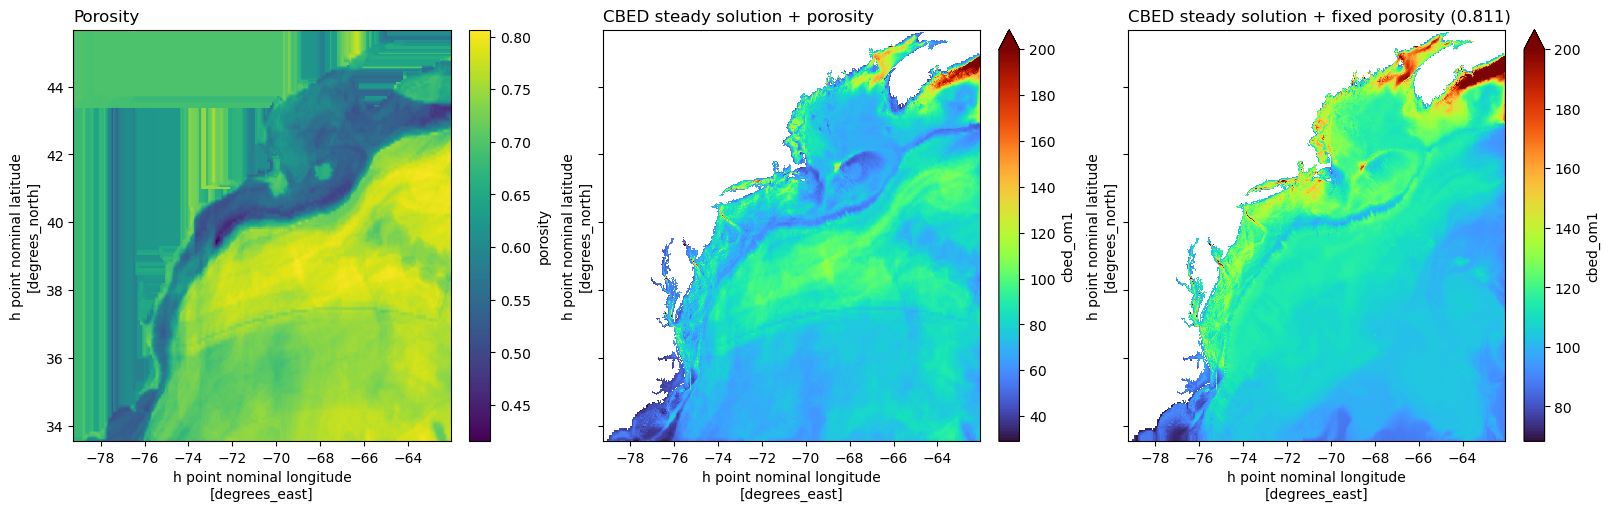

In [25]:
import matplotlib.pyplot as plt
ds1 = xr.open_dataset('../data/cbed_results_nopor.nc')
fig, ax = plt.subplots(nrows=1,
                       ncols=3,
                       sharex=True,
                       sharey=True,
                       figsize=[16,5],
                      constrained_layout=True)
dsout['porosity'].plot(ax=ax[0])
dsout['cbed_om1'][0].plot(vmax=200, cmap='turbo', ax=ax[1])
ds1['cbed_om1'][0].plot(vmax=200, cmap='turbo', ax=ax[2])

ax[0].set_title('Porosity',loc='left')
ax[1].set_title('CBED steady solution + porosity',loc='left')
ax[2].set_title('CBED steady solution + fixed porosity (0.811)',loc='left')

for a in ax:
    a.set_title('')
    # ax[0].axis('equal')